# Lab 062 · Trace the original TabPFN through a real prediction

[Lesson](../lessons/0062-tabpfn-v1.html) · [Reference](../reference/0062-tabpfn-v1.html) · [Measured author evidence](_verify_l062_v2_results.json) · [Sources](_sources_l062_v2.json) · [Reproduction contract](l062-reproduction.md)

**Mirror scope:** full historical v1 architecture and numeric inference recipe, with actual copied released weights and whole-wrapper source checks. Data tier A: real small paper datasets. Five live tasks feed a genuine pretrained prediction experiment. The offline SCM/BNN prior and 9.2 million-task training are explained but not newly run here. No random reduced encoder is passed off as TabPFN. The default lab predicts on full diabetes rows with one and four views plus a shuffled-context-label intervention; it does not optimize any Transformer weights. The larger author panel remains separately labeled reference evidence. Original paper-result reproduction: INCOMPARABLE.

### Running on Google Colab?

Colab opens only this single file, so the course package (`relkit`) and the lab
dependencies (xgboost, lightgbm, catboost, …) are **not** present by default. The cell
below fixes that: on Colab it shallow-clones the course repo, installs
`requirements-labs.txt`, and switches into `labs/` so `relkit` imports and the data cache
resolve. **On a local venv or your own Jupyter it does nothing — just run it and continue.**

In [ ]:
# @colab-bootstrap — PROVIDED. Makes the lab self-sufficient on Google Colab; a no-op elsewhere.
import os, sys

if "google.colab" in sys.modules:
    if not os.path.isdir("/content/relational"):
        !git clone --depth 1 https://github.com/Avistian/relational.git /content/relational
    %pip install -q -r /content/relational/requirements-labs.txt
    os.chdir("/content/relational/labs")
    print("Colab ready — working dir:", os.getcwd())
else:
    print("Not on Colab — using the local environment as-is.")

## Make the PFN idea a concrete tabular classifier

<a href="../lessons/0061-prior-data-fitted-networks.html">The GP PFN</a> established why synthetic query likelihood can teach a conditional predictor. TabPFN v1 turns that idea into a historical classifier with an explicit input contract and a frozen row Transformer. Treat preprocessing, row encoding, masked attention and view aggregation as one predictor: each determines what the fixed weights actually receive.

## What you will be able to reconstruct

A new classification table arrives with a few hundred labeled rows. In lessons 042–054, those rows drove an optimizer: initialize a network, compute a supervised loss, update its weights, select a checkpoint, then predict. TabPFN moves most of that learning into an earlier phase. Its weights have already learned from millions of synthetic classification tasks. At prediction time, the labeled table becomes **input to a frozen network**. Replacing context labels changes the prediction without changing a weight.

This lesson's tangible outcome is a working historical TabPFN v1 predictor whose normalization, attention, residual updates and ensemble reduction you can inspect and complete. The lab copies the actual released weights into your visible implementation and measures real predictions. This is **pretrained inference through your implementation**. It is not fresh pretraining and not a reproduction of the paper's aggregate benchmark. The distinction matters: correct randomly initialized attention does not yet implement a useful learned prediction algorithm.

The relational mission requires strong table baselines before claiming that database structure adds value. TabPFN provides a particularly different baseline: it transfers an inference procedure learned across tasks. Its row tokens still represent one flat feature table. They do not create entity relationships, temporal guarantees or database joins. Those remain properties of how we build the prediction task.

**Retrieve first, without scrolling:** What does the label enter in an ordinary MLP: its input or its loss? In lesson 061, why did the GP sampler have to draw context and query targets from one shared function? Could a query attend to its own feature token without seeing its target? Keep the last answer: v1 changes that edge for computation, not because the edge necessarily leaked a label.

## From a PFN objective to a tabular prior

A **prior** is a distribution over possible data-generating mechanisms before observing the current labeled table. Write a mechanism as φ. A draw of φ can specify a graph, its weights, noise levels, which nodes are observed and the classification thresholds. Conditional on this mechanism, draw a whole dataset D. Drawing a new mechanism for every row would destroy much of the shared structure that makes context useful.

The posterior predictive distribution, or **PPD**, averages predictions over mechanisms after conditioning on context Dᶜ:

`p(y* | x*, Dᶜ) = ∫ p(y* | x*, φ) p(φ | x*, Dᶜ) dφ`.

The integral denotes averaging over all allowed mechanisms, weighted by their posterior plausibility. In a joint SCM prior, the observed query features can themselves inform which mechanism is plausible; fixed-design notation often suppresses this additional conditioning. In practice this inference can be expensive. A prior-data fitted network learns an approximation `qθ(y* | x*, Dᶜ)` by repeatedly sampling tasks, hiding some labels and minimizing their negative log probabilities. θ denotes the Transformer weights. A query is simply a row whose label the network must predict. **Cross-entropy** for a class target y is `−log qθ(y)`, measured in natural-log units, or nats.

For a fixed context and query feature vector, expected cross-entropy decomposes into the entropy of the true conditional distribution plus `KL(p || qθ)`. Entropy is fixed when θ changes; KL is a nonnegative measure of distribution mismatch. Therefore the unrestricted optimum is the prior's PPD. The statement is about the selected prior and the ideal optimum. Finite training, finite capacity and a mismatch between synthetic and real data can all leave errors. The GP experiments in lesson 061 made those gaps measurable because their oracle was analytic; the full TabPFN prior has no comparably cheap exact oracle. [Paper §§2–4 and Algorithm 1](https://arxiv.org/html/2207.01848v6#S2).

The original v1 prior mixes two mechanism families with equal probability. A **Bayesian neural network prior** samples an architecture and weights, then produces targets from input features. A **structural causal model**, or SCM, specifies a directed acyclic graph and one noisy assignment for each node. A directed edge indicates that one node's value enters another node's generating function. An acyclic graph has no directed loop, so values can be generated in order. The SCM samples feature nodes and a target node from a sparse layered graph; the target can be a cause or an effect of observed features. Neither family means that the Transformer samples a new graph for each real prediction. Pretraining transfers the consequences of those sampled mechanisms into its weights.

The prior includes distributions over depth, hidden size, weight scale, noise, sparsity and activation. “Simple” here means the particular sampled families favor graphs with relatively few nodes and parameters; it is not a theorem that every simple real task will be easy. Graph sparsification, block sampling of observed nodes and feature-specific scales create differing interactions and correlations. Label generation first creates continuous targets, then samples thresholds, assigns interval IDs and permutes the IDs. This permits multiclass tasks and class imbalance without treating the numerical class ID as an inherently ordered semantic quantity.

For example, continuous targets `[-.4, .2, .8]` and thresholds `[-.1, .5]` produce interval IDs `[0,1,2]`. A sampled relabeling `[2,0,1]` can then turn them into `[2,0,1]`. Bounds are sampled from the generated task's target values; they are a property of the synthetic task construction, not a preprocessing rule fitted to real test labels. Lesson 063 will implement and interrogate that prior. Here we implement the learned predictor that consumes its consequences. [Paper §§4.1–4.5; Appendices C and E.4](https://arxiv.org/html/2207.01848v6#S4).

**CHECK your claim:** An SCM-based prior does not identify a causal graph from your table. The paper explicitly predicts associations directly without producing a graph. Observational prediction, an intervention such as setting a treatment and a counterfactual for one person are different targets. High classification accuracy establishes only the first of these unless the task and evidence establish more.

**Connecting the ideas.** The PFN principle explains why weights can stay fixed. The complete prediction route now explains how: construct context and query tokens, mix only permitted rows, decode the queries, then return probabilities in the original class order.

### TabPFN v1: one row token, many labeled-context interactions

**Trace before reading:** At which point can a context label affect a query prediction?

<div style="max-width:100%;overflow-x:auto">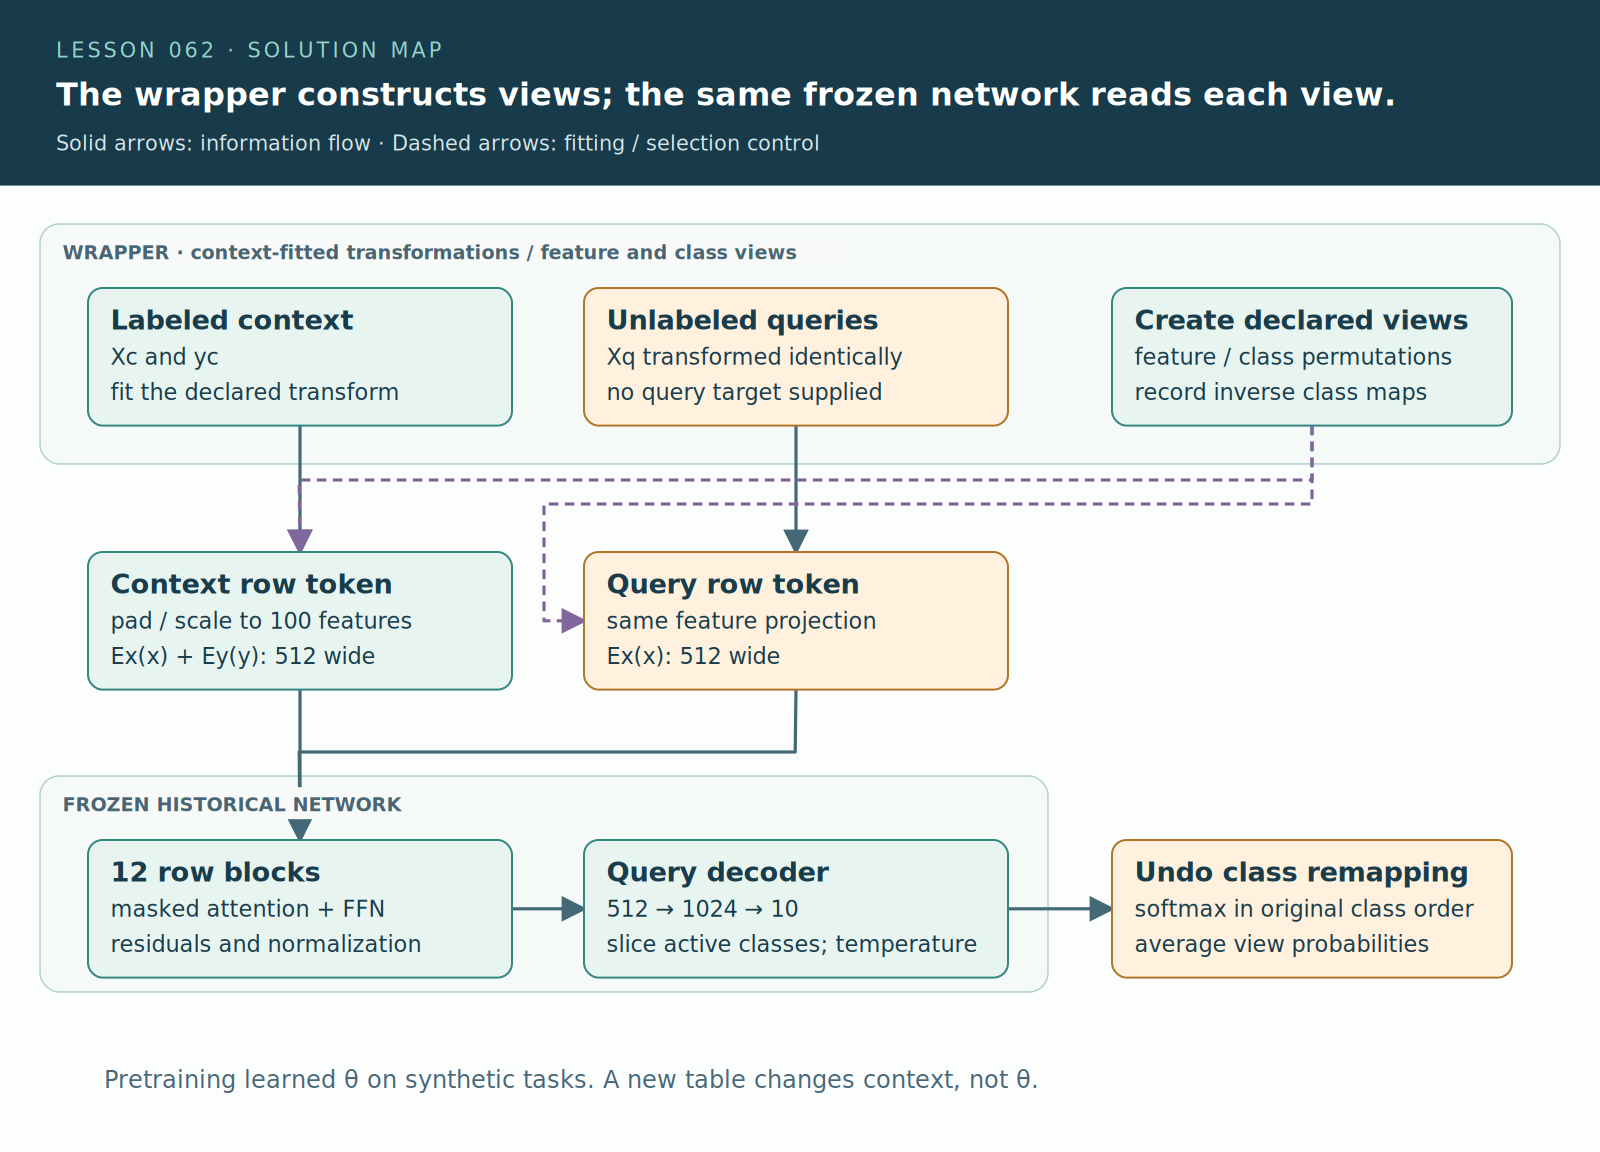</div>

**How the parts work together:** Only context tokens receive label embeddings. The query then reads those context states through the masked row blocks. After decoding each view, undo class permutations before combining probabilities.

**Pictured scope:** Historical v1 checkpoint; 12 row blocks, d=512, four heads, 100-feature input contract, up to ten native classes. View count and preprocessing are the declared lesson recipe.

[Full-size vector diagram](../assets/solution-maps/0062-historical-v1.svg). Scroll on narrow screens to keep labels legible.

<details><summary>Text route: components and connections</summary><ol><li><strong>Labeled context</strong>: Xc and yc; fit the declared transform. Connects to Context row token.</li><li><strong>Unlabeled queries</strong>: Xq transformed identically; no query target supplied. Connects to Query row token.</li><li><strong>Create declared views</strong>: feature / class permutations; record inverse class maps. Connects to Query row token (fitting/selection control); Context row token (fitting/selection control).</li><li><strong>Context row token</strong>: pad / scale to 100 features; Ex(x) + Ey(y): 512 wide. Connects to 12 row blocks.</li><li><strong>Query row token</strong>: same feature projection; Ex(x): 512 wide. Connects to 12 row blocks.</li><li><strong>12 row blocks</strong>: masked attention + FFN; residuals and normalization. Connects to Query decoder.</li><li><strong>Query decoder</strong>: 512 → 1024 → 10; slice active classes; temperature. Connects to Undo class remapping.</li><li><strong>Undo class remapping</strong>: softmax in original class order; average view probabilities.</li></ol></details>

## Model architecture

Let C be the number of context rows, Q the number of queries, F the number of active numeric features, B the number of independent tasks or views processed together, d the hidden width and H the number of attention heads. One **token** is the vector representation that attention treats as an element of its sequence. In v1, one token is a **whole row**, not an individual feature. The released model has d=512, H=4, 12 Transformer blocks, feed-forward width 1024 and a maximum of 10 output classes. Thus one head has 512/4=128 coordinates. The feature input has a fixed maximum width of 100.

Before tokenization, context-fitted transformations standardize features, optionally apply a power transform and compress outliers. After scaling and zero padding, the input is `B×(C+Q)×100`. A linear feature encoder maps each row to 512 coordinates. A separate linear label encoder maps a scalar context class ID to 512 coordinates. The context token is their sum:

`hᵢ⁰ = Wₓ xᵢ + bₓ + Wᵧ yᵢ + bᵧ`, for `i < C`.

The query token is only `hⱼ⁰ = Wₓ xⱼ + bₓ`. **There is no learned “unknown label” embedding on this released path.** A class-0 context row still has the label encoder's bias, while a query does not receive that encoder at all. No positional encoding is active: row order is not intended to carry meaning. The model signature accepts `x` and context `y`; it never needs a query target placeholder.

Every block first makes query, key and value projections from the current row states. A **query vector** asks which context information matters for the receiving token; keys determine compatibility; values carry the information to combine. These uses of “query” differ slightly: all rows produce attention query vectors, while only the unlabeled rows are prediction queries. Every receiving row can read context keys and values. No receiving row can read query keys or values.

The 12 blocks use the same kind of operation but have different weights. Their attention and feed-forward sublayers each have a residual addition followed by LayerNorm. **LayerNorm** normalizes across the hidden coordinates of each row and applies learned coordinate-wise scale and offset. It does not estimate population moments from the set of query rows. The feed-forward sublayer is Linear 512→1024, GELU, Linear 1024→512. GELU is a smooth nonlinear activation. The query states after block 12 enter Linear 512→1024, GELU, Linear 1024→10. Only the first K logits are used for a task with K observed classes.

The model has 25,821,706 learned parameters in the copied checkpoint. Pretraining updates these weights using held-out synthetic labels. Real-table inference keeps them fixed and changes only input features and context labels. The checkpoint stores additional training configuration, but serialized callable descriptions and settings such as local batch size do not establish that its metadata independently reconstructs the paper's distributed training run. [Paper E.1–E.3](https://arxiv.org/html/2207.01848v6#A5); released [`TransformerModel.forward`, `TransformerEncoderLayer.forward`](https://github.com/PriorLabs/TabPFN/tree/v1.0.0/tabpfn).

## Trace information access

For one head, let `U` contain the projected query vectors for all C+Q receivers and let `Kᶜ,Vᶜ` contain the projected context keys and values. The attention output is

`A = softmax(U (Kᶜ)ᵀ / √128) Vᶜ`.

The softmax acts over the **sending context row** dimension: each receiver gets weights summing to one. Scaling by the square root of the head width controls how dot-product magnitude grows with dimension. Splitting the projection into four heads lets each head combine its own value coordinates; concatenate the resulting heads and apply an output projection before the residual addition.

A rectangular matrix of `(C+Q)×C` scores has exactly `C²+CQ` entries per head. The original lesson-061 PFN could attend to each query's own feature token as well. Appendix E.2 explicitly removes these query self edges in v1. For C=3,Q=2, the old conceptual 5×5 mask allowed 17 entries; the v1 mask allows 15. The efficient implementation avoids forming blocked query columns, so it allocates 15 score entries rather than a full 25-entry matrix. This saving does not remove the C² context cost.

### Prove the sender boundary

Let P permute context rows. The query score row changes from s to sPᵀ, its softmax changes to softmax(s)Pᵀ, and values change from V to PV. Since PᵀP=I, the weighted sum stays the same. This proves a row-order property, not feature-column invariance. With repeated blocks, context states remain independent of query rows by induction. Each query's residual carries its own features, so excluding query keys does not make queries identical.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic width-2 head: context scores 0, 1 produce weights .268941, .731059 and output (.268941,1.462117). Query-key columns are blocked in every v1 layer." src="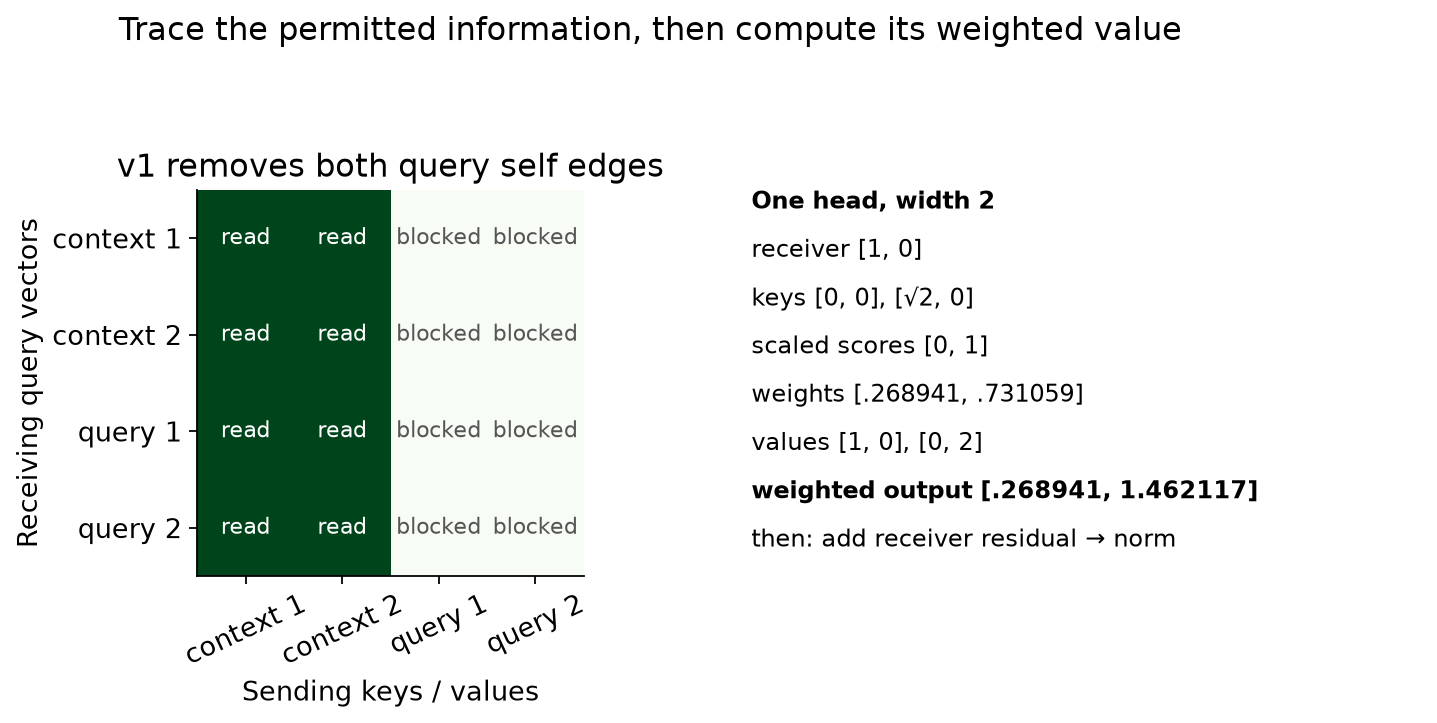" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

Synthetic width-2 head: context scores 0, 1 produce weights .268941, .731059 and output (.268941,1.462117). Query-key columns are blocked in every v1 layer. [Full-size figure](figures/l062/attention-v2.png).

A small fixture exposes the arithmetic. Take one head of width 2 with receiver `[1,0]`, context keys `[0,0]` and `[√2,0]`, and context values `[1,0]` and `[0,2]`. The scaled scores are `[0,1]`. Softmax gives approximately `[.268941,.731059]`. The weighted value is therefore `[.268941,1.462117]`. These are synthetic projected vectors, not recorded activations from the checkpoint. The figure holds scores and context fixed while changing an unrelated query's value; that value has no sending column, so the existing query's output cannot change.

Why can the model still distinguish two query rows if neither query can read itself? Its own features determine the query projection, and the residual preserves its state. With attention output a, the block does

`u = LayerNorm(h + a)` and `h′ = LayerNorm(u + W₂ GELU(W₁u+b₁)+b₂)`.

Removing self attention is not removing the row. Moving LayerNorm before these additions implements a different computation; copying pretrained weights into that different model is invalid even when every shape matches.

The independence argument must cover every layer. Context states only depend on context at layer 1, and this remains true inductively. Each prediction query combines those context states with its own residual path. A second query cannot change the first query through attention, through the row-wise feed-forward network or through LayerNorm. A whole-pipeline check is still needed: a transform fitted on all query rows would create a separate dependency before tokenization. Even context-only fitting is insufficient if transforming a new query triggers a fallback that changes previously transformed rows; the counterexample below exposes precisely that failure. Dropout must also be off for the deterministic comparison.

**Predict before CHECK:** Permute context rows and labels together. The context keys, values and attention weights permute together, so their weighted sum should be preserved up to floating-point error. Now exchange two feature columns without changing the encoder. There is no equivalent architectural guarantee: each input coordinate has its own encoder weights. Permuting row order, rotating feature indices and rotating the geometric feature space are three different transformations.

**Connecting the ideas.** The attention mask controls token communication, but the tokens come from a fitted transformation. A checkpoint trained on a particular scale and feature layout does not make arbitrary preprocessing equivalent. Audit the wrapper before blaming the network.

## Preprocessing is part of the predictor

Pretrained weights expect a particular distribution of inputs. “I copied the Transformer” is insufficient if I change the feature scaling or label mapping. On the audited numeric v1 path, each view starts with context-only sample means and standard deviations. The denominator uses sample standard deviation, with divisor C−1, plus 10⁻⁶. Standardized values are clipped to [−100,100]. Features constant in context are removed. Query rows do not decide which columns survive.

For a one-feature context `[1,3]`, mean=2 and sample standard deviation=√2. A query value 101 becomes approximately 70.7106 after standardization. A much larger query may hit the clamp, but it must not move the context's standardized values. Using `[1,3,101]` to fit the moments would change the existing context representation and make the prediction depend on which other queries happened to be submitted.

The optional Yeo–Johnson power transform estimates one transformation per feature on context rows and applies it to context and query. It can reduce skew and handles negative as well as positive values. Its parameter is not estimated from the query table. The released wrapper keeps the existing column when fitting or transforming it raises an exception; the lab preserves this behavior for the supported numeric path and checks it against the original implementation. Power transforms are view choices, not gradient updates to the Transformer.

**A measured failure of whole-wrapper isolation.** The audited historical wrapper catches an exception around both fitting the power transform and transforming the combined rows. An extreme extra query can make transformation overflow. The fallback then retains the untransformed column for the *entire* combined table, including context and the original query. Context-only fitting did not prevent this control-flow dependency. A reproducible 12-row one-feature context with values around 10⁻⁹ fits a Yeo–Johnson exponent about −219.54. Adding a query of −100 triggers an `expm1` overflow in the recorded environment. The original query's class 1 probability changes from .382355 to .484686 with four views; the released reference agrees within 1.4×10⁻⁶. The one-view none-transform control has zero observed difference. [Saved source-checked counterexample](_query_fallback_l062_results.json).

This is a historical wrapper behavior, not an attention-mask failure and not a silently repaired implementation. The notebook recreates it using your live predictor. The exact numerical trigger depends on the recorded library versions, but the structural lesson is broader: prove that preprocessing **including its failure path** stays fixed when proving pipeline independence. Ordinary batch-isolation fixtures pass; they do not establish a universal property.

Next comes **outlier softening**. The wrapper estimates context mean and standard deviation, identifies context values within four standard deviations, re-estimates moments on these retained values and uses the resulting lower/upper bounds for logarithmic tail compression. This is not simply deleting query rows or clipping all values to ±4. The implementation is visible because the exact transformation affects copied-weight predictions. Missing values survive these moment calculations until the feature encoder replaces them with zero. In this representation, zero does not retain an explicit missingness indicator; that limitation is consistent with the paper's weaker emphasis on missing data.

### A visible denominator is part of the learned model

Two context observations 1 and 3 have sample standard deviation √2, not 1. Their first standardized coordinate is approximately −.707106. Changing the denominator to population standard deviation gives −1. After multiplication by 100/k, this mismatch reaches every first-layer feature projection. Both results look normalized, but only one matches this checkpoint's trained input convention. Compare the whole wrapper as well as attention.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computational figure"><img alt="Context-only standardization trace plus a separate K=6 scaling/padding fixture. The actual checkpoint uses K=100; preprocessing and unknown-label semantics are part of the copied-weight function." src="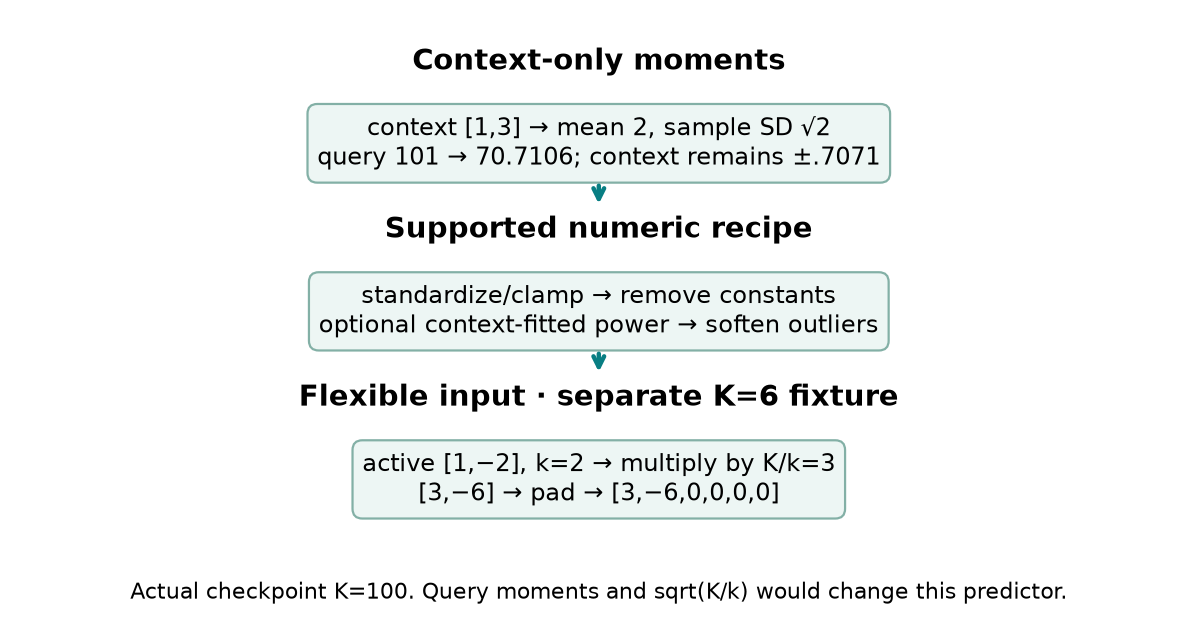" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

Context-only standardization trace plus a separate K=6 scaling/padding fixture. The actual checkpoint uses K=100; preprocessing and unknown-label semantics are part of the copied-weight function. [Full-size figure](figures/l062/preprocessing-v2.png).

Finally, with k surviving features and maximum K=100, multiply values by `K/k`, then append K−k zero columns. The paper calls this a flexible encoder: one fixed linear layer can accept tables with different feature counts. For the miniature K=6 fixture, `[1,−2]` becomes `[3,−6,0,0,0,0]`. The actual checkpoint uses K=100. Multiplication by √(K/k) is an available source option but is **not active in this checkpoint**. Nor does multiplying by K/k guarantee equal variance for every possible covariance structure; it is the specific magnitude convention learned during pretraining.

The supported lesson path handles numeric columns, context-fitted transformations, at most 100 input columns and 2–10 contiguous class IDs. It excludes ranking transforms, feature subsampling beyond 100, explicit categorical-column handling and query-fitted normalization. The official source contains these optional paths; passing our supported-path tests does not certify all of them. All-constant context features are rejected explicitly in this lab rather than silently producing a degenerate feature-count division.

**Connecting the ideas.** A preprocessing view can change feature order or class coding while preserving the task. Run the same fixed model on each declared view, undo class permutations, and only then combine outputs. Aggregation is the final part of the forward system.

## Ensembling means aligning the answer space

The released predictor can form several **views** of the same table. A view rotates feature-column indices, rotates class IDs and selects raw-standardized or power-transformed features. A column-index rotation by two changes `[x₁,x₂,x₃,x₄]` to `[x₃,x₄,x₁,x₂]`; it does not multiply features by a dense orthogonal rotation matrix. With F original columns and K classes there are at most 2FK rotation/transform combinations. Requesting more views cannot create more unique combinations in this procedure.

Class rotation is `y′=(y+s) mod K`. The predicted coordinate for original class j is therefore the rotated model's coordinate `(j+s) mod K`. Reverse this mapping **before** combining views. Otherwise one view's “class 0” means another event than a second view's “class 0”. The feature and label transformations apply consistently to context and query; only context labels are available.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computational figure"><img alt="Synthetic three-class fixture with temperature 1: undo class rotation before averaging logits. Historical wrapper temperature is .8. Probability averaging gives a different predictor." src="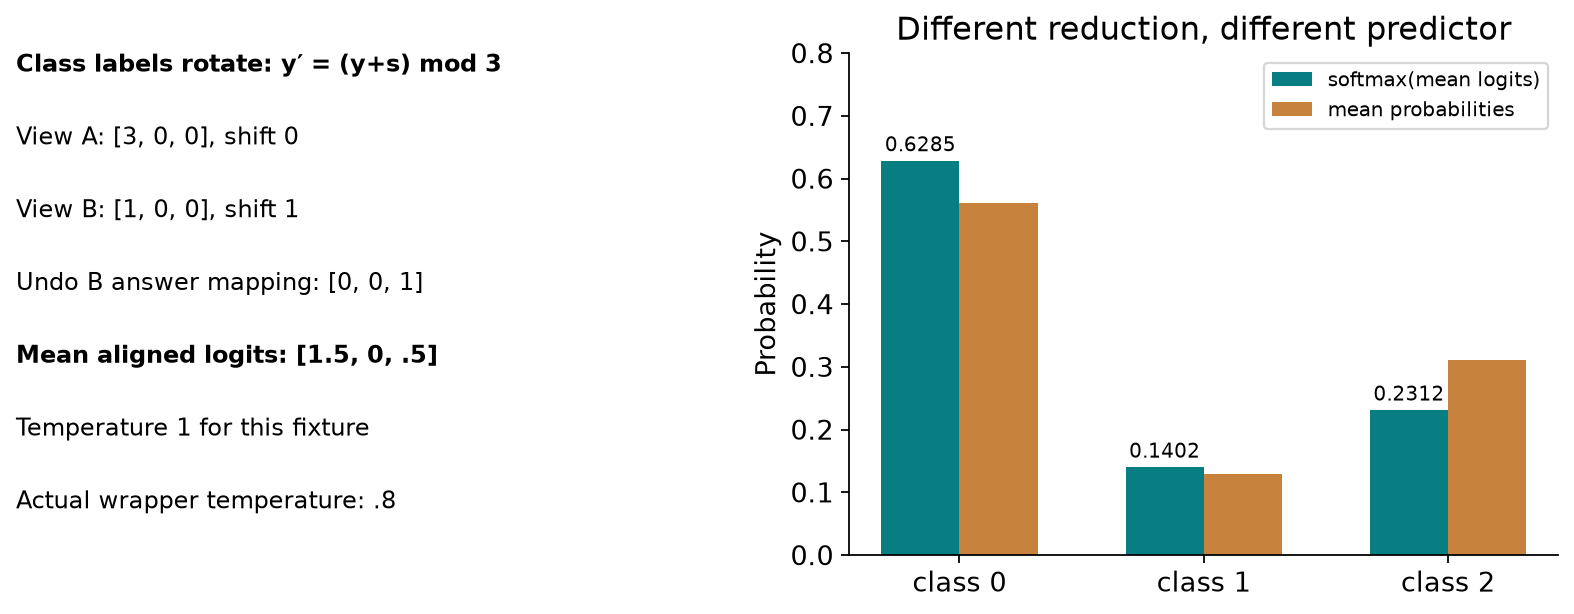" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

Synthetic three-class fixture with temperature 1: undo class rotation before averaging logits. Historical wrapper temperature is .8. Probability averaging gives a different predictor. [Full-size figure](figures/l062/ensemble-v2.png).

In the fixture, view A has logits `[3,0,0]` with shift 0. View B has logits `[1,0,0]` with shift 1. Rotate view B's answers back to `[0,0,1]`, then average to `[1.5,0,.5]`. With illustrative temperature 1, softmax gives about `[.6285,.1402,.2312]`. Averaging each view's probabilities instead produces a different distribution. The historical 0.1.11 wrapper defaults to **averaging aligned logits**, then dividing by temperature .8 and applying softmax. Temperature smaller than one makes a fixed unequal logit vector sharper; it does not change which coordinate is largest.

This detail is derived from `transformer_predict`, not inferred from the paper's generic word “ensemble”. Its default ordering alternates none/power views within a sampled pair of rotations. A single requested view therefore uses the none transformation; it is not a random 50/50 choice between none and power. The random seed chooses view rotations; it does not retrain the checkpoint. Constant-feature removal occurs after the source draws feature shifts from the original column count. The lesson preserves this slightly awkward slicing behavior so its wrapper actually matches the released predictor.

The ensemble encourages robustness to arbitrary column and class indexing, but a finite collection of cyclic rotations is not all possible permutations. Pretraining rotations can encourage learned invariance without proving exact invariance. Keep the exact context-row permutation argument separate from these empirical transformations.

## Run the historical model

The original reference is the `tabpfn==0.1.11` wheel, identified by a SHA-256 digest, and the released `prior_diff_real_checkpoint_n_0_epoch_42.cpkt` checkpoint with SHA-256 beginning `3c9aadae`. A digest identifies exact bytes. The lab independently implements the inference mechanism, copies every model weight with a strict key/shape check and excludes only the criterion's class-weight buffer from the mapping. It imports the released package only for validation. You can read the complete model and inference wrapper in the notebook.

Validation has three layers. Small exact fixtures expose the intended arithmetic. Full copied-weight forward and gradient comparisons establish parity with the named source computation. Finally, complete wrapper comparisons cover binary and multiclass data, a constant feature, missing numeric entries and an extreme query. Context permutation, context-label sensitivity and query batching probe complementary properties. A predictor returning the same constant distribution for everything could pass a query-isolation check, which is why isolation alone is weak evidence.

The actual executed teacher run completes your five live functions and passes them into a real inference experiment. The functions are not decorative exercises followed by an imported completed model. Call counters verify that preprocessing, attention, residual updates and ensemble aggregation execute downstream. Kernel identity records the actual visible functions, class methods, defaults, keyword defaults, configs and dependency versions. Repository source hashes are reference identity; they do not certify an edited notebook kernel. A mutation CHECK changes a helper, method, default and preset and requires their identities to change. No checkpoint resume is offered.

**Connecting the ideas.** The historical package and checkpoint make the function identifiable. The experiment measures that function under a particular context, view policy and task set. Source correspondence and benchmark performance remain different claims.

## What was measured here

**Prediction before results:** Will four views improve every split over one view? Does giving correct context labels outperform shuffling them? Write the direction you expect and one reason it might fail on an individual small test set. The first intervention changes a fixed inference recipe; the second removes much of the legitimate feature-label relationship while preserving label counts. Neither is new pretraining.

The new author panel uses diabetes (OpenML 37), blood transfusion (1464) and Wisconsin diagnostic breast cancer (the same UCI dataset available as sklearn `load_breast_cancer`, OpenML 1510 in the paper). All rows are retained. For each dataset, three stratified 50/50 splits use seeds 0,1,2; both view budgets share the exact rows and labels. We compare one and four views of the same frozen checkpoint. **AUC**, area under the receiver operating characteristic curve, measures ranking of positive relative to negative examples. Binary **log loss** scores the probabilities assigned to actual labels; lower is better. Both are recorded with individual predictions and view logits. The raw features and labels have separate hashes, and row indices are retained.

### Three different claims require three different checks

Copied-weight parity asks whether two implementations compute the same function. A real-data inference experiment asks what that frozen function predicts on named rows. Repeating the paper's benchmark asks whether the complete dataset, split, preprocessing, view, baseline-selection and metric protocol was recovered. Passing the first two does not automatically pass the third. The new records keep view logits and class shifts so probability aggregation can be independently reconstructed.

<div style="overflow-x:auto;max-width:100%" role="region" aria-label="Scrollable computational figure"><img alt="New author-reference pretrained inference: paired 1/4-view log losses on full data, three stratified 50/50 splits per dataset. Lines connect the same split; shared y-axis. These are overlapping split variations, not independent-dataset confidence intervals." src="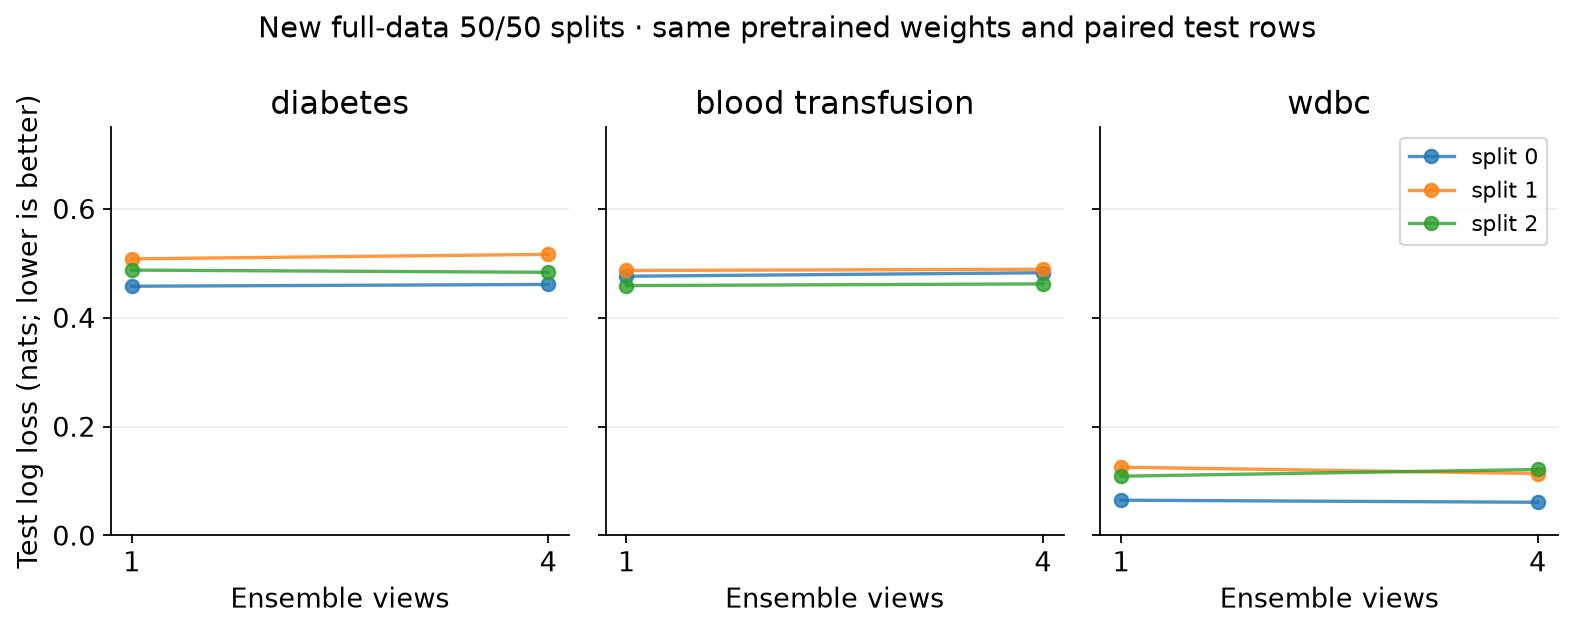" style="width:760px;min-width:640px;max-width:none;height:auto"></div>

New author-reference pretrained inference: paired 1/4-view log losses on full data, three stratified 50/50 splits per dataset. Lines connect the same split; shared y-axis. These are overlapping split variations, not independent-dataset confidence intervals. [Full-size figure](figures/l062/results-v2.png).

Read the points within each dataset first. Means and sample standard deviations summarize the three split/view-seed combinations. They are descriptive variation over overlapping resamples of the same dataset, not independent-dataset confidence intervals. No Friedman test or critical-difference claim is appropriate for this two-budget mechanism comparison. The three datasets are not enough to recover the paper's full model ranking, and repeated splits do not create new datasets.

The paper's main result evaluates 18 numeric datasets without missing values, drawn from a 30-dataset OpenML-CC18 subset with at most 2,000 rows, 100 features and 10 classes. It uses five 50/50 splits and normally 32 views. Baselines receive declared tuning budgets and use their own prescribed preprocessing. The local panel aligns the dataset identities, full-row small-data regime, 50/50 split proportion and pretrained model family. It differs in dataset count, view budget, number of splits, exact split construction/row order and absence of tuned competing baselines. WDBC comes from sklearn's UCI copy rather than a proven byte-and-order match to the paper's OpenML representation. Therefore every local score is **INCOMPARABLE to aggregate paper-result reproduction**, even when numerically close to an individual published score. [Paper §5.2, Tables 1–2, F.3](https://arxiv.org/html/2207.01848v6#S5.SS2).

Appendix F.3 constructs 150 meta-validation datasets; Appendix B.5 drops flags because enough valid splits could not be generated, leaving 149 evaluated datasets. These datasets informed method development; they are not 149 untouched meta-test datasets. Its prior ablation uses smaller training budgets and compares BNN, SCM and their mixture; those results do not isolate a particular encoder or prove that causal priors dominate all other priors. Our pretrained ablations cannot re-estimate that prior-training comparison. The older local three-task/180-context result remains available under its original filenames and operator identity. It has not been relabeled as this full-data visible-model run.

## What “a second” measures

The title's speed claim has a denominator. The paper measures downstream preparation and prediction after the model is already loaded, with CPU and GPU figures reported separately. It excludes one-time prior-fitting, just as its comparisons exclude baseline algorithm-development and meta-learning costs. The paper reports approximately .62 seconds on its GPU for the 32-view procedure; a CPU measurement, a cold download or another number of views is a different workload. Quoting .62 seconds beside a locally measured CPU quality result would splice together two systems. [Paper Table 1 and F.1/F.5](https://arxiv.org/html/2207.01848v6#A6).

In the local runner, the timer includes numeric preprocessing and model inference, but excludes data loading and checkpoint loading. It uses one CPU thread. The wrapper recomputes context states for each query chunk; it does not claim a context-cache speedup. Batching changes how often this context computation is repeated and how much memory is allocated. The rectangular attention still has C²+CQ score work per head per layer, while feature projections and feed-forward layers add substantial dense-matrix work. A score-count diagram is not a measured runtime model.

Original prior-fitting used 18,000 batches of 512 synthetic datasets, or 9,216,000 datasets, with sequences of 1,024 rows, a random context/query split, 12 layers and Adam with warm-up/cosine scheduling. The paper reports about 20 hours on eight RTX 2080 Ti GPUs and selects among three learning rates by final training loss. This course has not repeated that training. A pretrained checkpoint cannot be counted as newly reproduced prior fitting. The supplied closer track raises the local inference protocol to five splits and up to 32 views using the same visible implementation; it remains a subset reproduction attempt, with no cloud job launched by default.

## Where this architecture sits

**Versus FT-Transformer:** FT-Transformer makes feature tokens within one row and learns task-specific weights from that table. TabPFN v1 compresses the entire row into one token and communicates across labeled rows. A numeric feature's influence in v1 starts in its input projection coordinate; there is no explicit feature-token attention map to inspect. More context can change v1's answer while leaving all pretrained weights fixed.

**Versus TabTransformer:** TabTransformer contextualizes categorical embeddings within a row before its supervised prediction network. Its unlabeled-data pretraining and task-specific supervised fine-tuning are different from repeatedly learning to infer labels across synthetic supervised tasks. Calling both “pretrained Transformers” misses what the training target and inference input are.

**Versus SAINT:** SAINT's row attention also allows examples to interact, but its training recipe and batch semantics differ. A row-attention axis alone does not make a model a PFN. The defining extra ingredients are prior-generated shared tasks, a held-out query objective and the context/query information boundary carried into inference.

**Versus TabR:** TabR retrieves training examples as task-specific memory and learns a retrieval/prediction mechanism on the downstream table. TabPFN's full context is memory for a mechanism already learned elsewhere. Both can use labels from legitimate training rows, and both need the task's temporal or group boundary to decide which rows are legitimate. Neither can make a random split valid for predicting future customer behavior.

**Versus lesson 061 and the next lessons:** We keep the PFN objective but replace the fixed GP family and scalar density head with a rich tabular classification prior and class logits. The released v1 architecture removes query self edges, supports a fixed padded feature budget and combines inference views. Lesson 063 examines what the SCM generator assumes; lesson 064 changes the representation and scaling story. Learning these distinctions prepares you to diagnose which part of a foundation model needs to change when a database task exceeds its context, feature, class or prior assumptions.

## Exit and teach-back

The runnable notebook contains five substantive live tasks: context normalization; feature scaling/padding; rectangular attention; postnorm residual updates; and class-aligned logit aggregation. Each has an immediate diagnostic CHECK. The default experiment then runs the full pretrained model using your functions, compares one and four views, and shuffles context labels while keeping its query targets hidden until scoring. The EXIT saves your kernel identity, source parity checks, model/checkpoint identity, exact rows, probabilities and your written interpretation.

**Explain without looking:** A colleague says, “No optimizer runs on my table, so context labels cannot affect the answer.” Trace the first operation where that claim fails. Then explain why a second query cannot affect an existing query inside the Transformer, and how the measured preprocessing fallback invalidates a universal whole-wrapper claim. Finally distinguish code parity, pretrained inference and original paper-result reproduction in three sentences.

Bring the EXIT artifact and any failed CHECK back to the teacher. A notebook that runs after importing a hidden completed replacement is not evidence that you can reconstruct the mechanism. The next useful step is to predict and inspect one mismatch: change a live operator, observe the source-parity failure, and explain the pathway that changed before restoring it.

## Start the live implementation
Every provided class resolves its helper functions in this notebook. The pretrained weight loader receives your model class; the experiment receives that actual model instance. The reference package checks the result but does not replace the mechanism you are implementing. Read each coherent chunk before running it.

In [ ]:
# PROVIDED — imports, paths and explicit local artifact folder
import hashlib,inspect,importlib.metadata,itertools,json,math,random,time,warnings,functools,sys
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from torch import nn
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import log_loss,roc_auc_score
from sklearn.model_selection import train_test_split
from IPython.display import display
for path in [Path.cwd(),Path.cwd()/'labs',Path.cwd().parent]:
    if (path/'relkit').is_dir():ROOT=path.resolve();sys.path.insert(0,str(ROOT));break
else:raise RuntimeError('Run bootstrap or start in labs')
__file__=str(ROOT/'relkit/tabpfn_l062_v2.py')  # reference source identity only, never live-kernel identity
output=ROOT/'data/cache/l062-student';output.mkdir(parents=True,exist_ok=True)
torch.set_num_threads(1)
VERSIONS={k:importlib.metadata.version(k) for k in ['numpy','torch','scipy','scikit-learn']}
print(VERSIONS)

In [ ]:
# PROVIDED — immutable checkpoint and declared configuration
CHECKPOINT_SHA='3c9aadaeddbf51462af8c0ee4b3ca3c697890f77e92318abbb0821b75261c392'
CHECKPOINT_URL='https://raw.githubusercontent.com/PriorLabs/TabPFN/v1.0.0/tabpfn/models_diff/prior_diff_real_checkpoint_n_0_epoch_42.cpkt'
MODEL_CONFIG={'features': 100, 'width': 512, 'heads': 4, 'hidden': 1024, 'layers': 12, 'classes': 10}
PRESETS={'smoke': {'datasets': ['diabetes'], 'seeds': [0], 'cap': 120, 'views': [1, 4]}, 'lab': {'datasets': ['diabetes', 'blood_transfusion', 'wdbc'], 'seeds': [0, 1, 2], 'cap': None, 'views': [1, 4]}, 'closer': {'datasets': ['diabetes', 'blood_transfusion', 'wdbc'], 'seeds': [0, 1, 2, 3, 4], 'cap': None, 'views': [1, 32]}}

### PROVIDED · Sample moments with missing entries
Count valid values per feature, compute their mean, then sum squared deviations and divide by count−1. The helper returns sample standard deviation. All-missing or one-valid-value columns have undefined moments; later handling follows the declared numeric wrapper and is not a general missing-data model.

In [ ]:
# PROVIDED — context moment arithmetic
def masked_moments(x,mask):
    count=mask.sum(0);mean=torch.where(mask,x,0).sum(0)/count
    std=(torch.where(mask,(x-mean).square(),0).sum(0)/(count-1)).sqrt()
    return mean,std

## TODO 1 · Fit normalization only on context

**Goal:** Return standardized N×F rows using context sample moments, epsilon 1e-6, and the source clamp. Reject fewer than two context rows.

**Why:** An apparently correct attention mask cannot undo query-dependent preprocessing.

**Hint boundary:** masked_moments is provided. The first n rows alone determine moments.

In [ ]:
# TODO — normalize_context
def normalize_context(x,n):
    raise NotImplementedError("Implement this live TabPFN operation")

In [ ]:
# CHECK — held-out extremes cannot move context statistics
fixture=torch.tensor([[1.,2.],[3.,6.],[101.,-100.]])
z=normalize_context(fixture,2)
assert torch.allclose(z[0],torch.tensor([-.7071063,-.7071065]),atol=1e-6), 'Use sample std and context rows only'
changed=fixture.clone();changed[-1]*=100
assert torch.equal(z[:2],normalize_context(changed,2)[:2]), 'Query-fitted statistics leak through preprocessing'
assert z.abs().max()<=100
print('Context-only sample moments and clamp pass')

### PROVIDED · Outlier compression
The first moment pass finds an inlier subset of context; the second establishes its bounds. Two maximum/minimum operations compress extreme tails logarithmically. Query values are transformed using those context-fitted bounds. This function calls the same visible moment helper.

In [ ]:
# PROVIDED — two-pass outlier softening
def soften_outliers(x,n,n_sigma=4):
    """Two context moment passes; logarithmic tail compression, not hard clipping."""
    c=x[:n];mean,std=masked_moments(c,~torch.isnan(c))
    mask=(c>=mean-n_sigma*std)&(c<=mean+n_sigma*std)&~torch.isnan(c)
    mean,std=masked_moments(c,mask);lo,hi=mean-n_sigma*std,mean+n_sigma*std
    x=torch.maximum(-torch.log1p(x.abs())+lo,x)
    return torch.minimum(torch.log1p(x.abs())+hi,x)

## TODO 2 · Adapt the fixed feature encoder

**Goal:** Scale k active columns using the historical K/k convention, then append exact zeros to reach K. Reject k outside 1..K.

**Why:** The released weights learned this magnitude convention; changing it changes the function.

**Hint boundary:** Compute k before padding. Padding has no trainable parameters.

In [ ]:
# TODO — scale_pad
def scale_pad(x,max_features=100):
    raise NotImplementedError("Implement this live TabPFN operation")

In [ ]:
# CHECK — fixed input width, factor K/k and exact zero tail
z=scale_pad(torch.tensor([[1.,-2.]]),6)
assert torch.equal(z,torch.tensor([[3.,-6.,0.,0.,0.,0.]])), 'Use K/k, then pad; sqrt scaling changes the pretrained input'
print('Flexible input scaling passes')

### PROVIDED · Prepare each numeric view
This function calls your context normalization, removes context-constant columns and optionally fits a Yeo–Johnson power transform to each context column. It then softens outliers. Scaling/padding occurs after the view rotates feature indices. Exception handling preserves the input column when that power transform fails, as on the named released path.

In [ ]:
# PROVIDED — whole numeric transform
def preprocess_numeric(x,n,transform='none'):
    """Numeric v1 wrapper subset: context moments, constants, power, outliers.
    Missing input values are retained until the model's explicit nan_to_num.
    No categorical indices, ranking, feature subsampling or query-fitted moments.
    """
    if transform not in ['none','power_all']:raise ValueError('Unsupported transform')
    z=normalize_context(x,n)
    keep=torch.tensor([len(torch.unique(z[:n,j]))>1 for j in range(z.shape[1])],device=z.device)
    z=z[:,keep]
    if z.shape[-1]==0:raise ValueError('All features are constant in context')
    if transform=='power_all':
        a=z.detach().cpu().numpy().copy()
        for j in range(a.shape[1]):
            with warnings.catch_warnings():
                warnings.simplefilter('error')
                try:
                    pt=PowerTransformer(standardize=True).fit(a[:n,j:j+1])
                    a[:,j:j+1]=pt.transform(a[:,j:j+1])
                except (ValueError,RuntimeWarning,UserWarning,FloatingPointError):pass
        z=torch.tensor(a,dtype=x.dtype,device=x.device)
    return soften_outliers(z,n),keep

## TODO 3 · Read the context memory

**Goal:** Return scaled dot-product attention for B×H×receivers×headwidth projections, with keys/values already restricted to context.

**Why:** Wrong softmax axes produce plausible shapes while mixing the wrong conditional distributions.

**Hint boundary:** The final score axis enumerates sending context rows; the scale uses one head’s width.

In [ ]:
# TODO — attention_mix
def attention_mix(q,k,v):
    raise NotImplementedError("Implement this live TabPFN operation")

In [ ]:
# CHECK — analytic two-sender fixture and receiver independence
q=torch.tensor([[[[1.,0.],[0.,1.]]]]);k=torch.tensor([[[[0.,0.],[2**.5,0.]]]]);v=torch.tensor([[[[1.,0.],[0.,2.]]]])
a=attention_mix(q,k,v)
assert torch.allclose(a[0,0,0],torch.tensor([.26894142,1.46211716]),atol=1e-6), 'Scale by head width and normalize over senders'
assert torch.allclose(a[:,:,0],attention_mix(q[:,:,:1],k,v)[:,:,0]), 'An unrelated receiver must not alter the first receiver'
print('Rectangular scaled attention passes')

## TODO 4 · Preserve the two residual pathways

**Goal:** Use the provided block modules to perform attention add/norm, then GELU feed-forward add/norm.

**Why:** Pre-normalization and post-normalization are different functions with the same parameter shapes.

**Hint boundary:** block exposes norm1,norm2,ff1,ff2. Track which state enters each addition.

In [ ]:
# TODO — postnorm_update
def postnorm_update(h,attention_output,block):
    raise NotImplementedError("Implement this live TabPFN operation")

### PROVIDED · Complete repeated block and row model
Follow B×N×512 through a packed qkv projection into four 128-wide heads. The key/value slice supplies only context rows to your attention function. All receiver states still enter your residual update. There is no query-label encoder call. The model's public forward receives context labels only, returns query logits only, and constructs 12 distinct blocks for the checkpoint.

In [ ]:
# PROVIDED — V1Block
class V1Block(nn.Module):
    def __init__(self,width,heads,hidden):
        super().__init__();self.width=width;self.heads=heads
        if width%heads:raise ValueError('heads must divide width')
        self.qkv=nn.Linear(width,3*width);self.out=nn.Linear(width,width)
        self.ff1=nn.Linear(width,hidden);self.ff2=nn.Linear(hidden,width)
        self.norm1=nn.LayerNorm(width);self.norm2=nn.LayerNorm(width)
        nn.init.xavier_uniform_(self.qkv.weight);nn.init.zeros_(self.qkv.bias)
        for layer in [self.out,self.ff2]:nn.init.zeros_(layer.weight);nn.init.zeros_(layer.bias)
    def forward(self,h,n):
        b,t,d=h.shape
        q,k,v=self.qkv(h).reshape(b,t,3,self.heads,d//self.heads).permute(2,0,3,1,4)
        # Rectangular attention computes n*n + query*n scores; no query self edge.
        mixed=attention_mix(q,k[:,:,:n],v[:,:,:n])
        mixed=mixed.transpose(1,2).reshape(b,t,d)
        return postnorm_update(h,self.out(mixed),self)

In [ ]:
# PROVIDED — TabPFNv1
class TabPFNv1(nn.Module):
    def __init__(self,features=100,width=512,heads=4,hidden=1024,layers=12,classes=10):
        super().__init__();self.config=dict(features=features,width=width,heads=heads,hidden=hidden,layers=layers,classes=classes)
        self.x_encoder=nn.Linear(features,width);self.y_encoder=nn.Linear(1,width)
        self.blocks=nn.ModuleList([V1Block(width,heads,hidden) for _ in range(layers)])
        self.head=nn.Sequential(nn.Linear(width,hidden),nn.GELU(),nn.Linear(hidden,classes))
    def forward(self,x,y):
        # x:B×(C+Q)×100, y:B×C. Query labels cannot enter this signature.
        n=y.shape[1]
        if x.ndim!=3 or y.ndim!=2 or x.shape[0]!=y.shape[0] or not 1<=n<x.shape[1]:raise ValueError('Bad context/query shape')
        h=self.x_encoder(torch.nan_to_num(x))
        h=torch.cat([h[:,:n]+self.y_encoder(y.to(x.dtype).unsqueeze(-1)),h[:,n:]],dim=1)
        for block in self.blocks:h=block(h,n)
        return self.head(h[:,n:])

In [ ]:
# CHECK — nonzero residual/FFN fixture distinguishes norm order
b=V1Block(8,2,16);torch.manual_seed(82)
for p in b.parameters():p.data.normal_(0,.2)
h=torch.randn(2,4,8);a=torch.randn_like(h)
z=b.norm1(h+a);expected=b.norm2(z+b.ff2(torch.nn.functional.gelu(b.ff1(z))))
assert torch.allclose(postnorm_update(h,a,b),expected), 'Two post-addition norms, with GELU only inside FFN'
print('Postnorm residual computation passes')

### PROVIDED · Strict copied-weight mapping and view order
The loader verifies checkpoint bytes before reading its state. Mapping names does not change tensor values; load_state_dict(strict=True) rejects missing/unexpected model parameters. The criterion buffer is not an inference parameter. view_configurations reproduces the historical random ordering with a local generator; the seed changes views, not weights.

In [ ]:
# PROVIDED — load_pretrained
def load_pretrained(path,model=None):
    """Strict complete weight mapping; criterion buffer is the only non-model entry."""
    path=Path(path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Unexpected checkpoint bytes')
    state,_,config=torch.load(path,map_location='cpu',weights_only=False)
    state={k.removeprefix('module.'):v for k,v in state.items()}
    model=TabPFNv1(**MODEL_CONFIG) if model is None else model
    mapped={}
    for key,value in state.items():
        if key=='criterion.weight':continue
        new=key.replace('transformer_encoder.layers.','blocks.').replace('self_attn.in_proj_weight','qkv.weight').replace('self_attn.in_proj_bias','qkv.bias').replace('self_attn.out_proj.','out.').replace('linear1.','ff1.').replace('linear2.','ff2.')
        if new.startswith('encoder.'):new='x_encoder.'+new[len('encoder.'):]
        if new.startswith('decoder.'):new='head.'+new[len('decoder.'):]
        mapped[new]=value
    model.load_state_dict(mapped,strict=True);model.eval()
    return model,config

In [ ]:
# PROVIDED — view_configurations
def view_configurations(features,classes,views,seed=0):
    """Match historical torch+Python ordering; none/power alternate per rotation."""
    if views<1:raise ValueError('At least one view')
    generator=torch.Generator().manual_seed(seed)
    fs=torch.randperm(features,generator=generator).tolist()
    cs=torch.randperm(classes,generator=generator).tolist()
    pairs=list(itertools.product(cs,fs));random.Random(seed).shuffle(pairs)
    return [(c,f,t) for (c,f),t in itertools.product(pairs,['none','power_all'])][:views]

## TODO 5 · Align classes before combining views

**Goal:** Restrict to active classes, undo each cyclic label shift, average logits, temperature-scale, and softmax. Validate dimensions and positive temperature.

**Why:** Averaging unaligned outputs combines probabilities for different events. Averaging probabilities is also a different recipe.

**Hint boundary:** A class originally named j was renamed (j+s)%K. Align output coordinates using that relation.

In [ ]:
# TODO — aggregate_views
def aggregate_views(logits,shifts,classes,temperature=.8):
    raise NotImplementedError("Implement this live TabPFN operation")

In [ ]:
# CHECK — rotate back before mean logits; temperature then softmax
logits=torch.tensor([[[3.,0.,0.]],[[1.,0.,0.]]]);p=aggregate_views(logits,[0,1],3,temperature=1.)
expected=torch.softmax(torch.tensor([[1.5,0.,.5]]),-1)
assert torch.allclose(p,expected), 'Undo y->(y+s)%K in the prediction axis before averaging'
wrong=(logits[0].softmax(-1)+torch.roll(logits[1],-1,-1).softmax(-1))/2
assert not torch.allclose(p,wrong), 'Averaging probabilities is a distinct ensemble'
print('Class alignment, logit averaging and temperature pass')

## PROVIDED · Connect the full predictor
Read the complete path: context/query concatenate → each transform → rotations → your scale/pad → your model → your class-aligned aggregation. Query chunks limit memory but this implementation recomputes context states per chunk; it does not claim caching. Raw per-view logits and configurations are returned so the final probabilities can be reconstructed independently.

In [ ]:
# PROVIDED — predict_numeric
def predict_numeric(model,context_x,context_y,query_x,views=4,seed=0,query_batch=256):
    """Full numeric inference recipe using the learner's model and five live tasks."""
    cx=torch.as_tensor(context_x,dtype=torch.float32);qx=torch.as_tensor(query_x,dtype=torch.float32)
    y=torch.as_tensor(context_y,dtype=torch.long);classes=len(torch.unique(y))
    if not torch.equal(torch.unique(y),torch.arange(classes)) or not 2<=classes<=10:raise ValueError('Encode context classes as contiguous 0..K-1')
    if cx.shape[1]!=qx.shape[1] or cx.shape[1]>100:raise ValueError('Feature dimensions')
    configs=view_configurations(cx.shape[1],classes,views,seed);n=len(cx)
    transformed={t:preprocess_numeric(torch.cat([cx,qx]),n,t)[0] for t in {c[2] for c in configs}}
    outputs=[];model.eval()
    with torch.no_grad():
        for shift,feature_shift,transform in configs:
            z=transformed[transform]
            # Source draws shifts before constant-feature removal; slicing preserves its behavior.
            z=torch.cat([z[:,feature_shift:],z[:,:feature_shift]],-1)
            z=scale_pad(z,model.config['features']);yc=((y+shift)%classes).float()[None]
            chunks=[]
            for query in z[n:].split(query_batch):chunks.append(model(torch.cat([z[:n],query])[None],yc)[0])
            outputs.append(torch.cat(chunks))
    logits=torch.stack(outputs)
    return aggregate_views(logits,[c[0] for c in configs],classes),{'configurations':configs,'logits':logits.tolist(),'temperature':.8}

In [ ]:
# PROVIDED — ensure_checkpoint
def ensure_checkpoint(root):
    import urllib.request
    path=Path(root)/'data/cache/foundation/v1/models_diff/prior_diff_real_checkpoint_n_0_epoch_42.cpkt'
    if not path.exists():
        path.parent.mkdir(parents=True,exist_ok=True);urllib.request.urlretrieve(CHECKPOINT_URL,path)
    if hashlib.sha256(path.read_bytes()).hexdigest()!=CHECKPOINT_SHA:raise ValueError('Checkpoint hash mismatch')
    return path

In [ ]:
# PROVIDED — load_dataset
def load_dataset(name):
    """All rows, numeric paper datasets. wdbc is sklearn's same UCI source (569×30)."""
    if name=='wdbc':
        from sklearn.datasets import load_breast_cancer
        data=load_breast_cancer();x=data.data;y=data.target
    else:
        from relkit.data import load_tier_a
        x,y=load_tier_a(name);x=np.asarray(x,dtype=np.float32);y=np.asarray(y)
    _,y=np.unique(y,return_inverse=True)
    return np.asarray(x,dtype=np.float32),y

In [ ]:
# PROVIDED — run_experiment
def run_experiment(root,preset='lab',model=None,config=None):
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import log_loss,roc_auc_score
    cfg=dict(PRESETS[preset] if config is None else config)
    model,_=load_pretrained(ensure_checkpoint(root)) if model is None else (model,None)
    result=dict(preset=preset,config=cfg,checkpoint_sha256=CHECKPOINT_SHA,records=[],datasets={},status='INCOMPARABLE',scope='Pretrained inference through visible model; no new pretraining; paper dataset subset and local split seeds')
    for name in cfg['datasets']:
        x,y=load_dataset(name)
        result['datasets'][name]={'shape':list(x.shape),'x_sha256':hashlib.sha256(x.tobytes()).hexdigest(),'y_sha256':hashlib.sha256(y.tobytes()).hexdigest()}
        for seed in cfg['seeds']:
            ids=np.arange(len(y))
            if cfg['cap'] is not None:ids=train_test_split(ids,train_size=cfg['cap'],stratify=y,random_state=620)[0]
            tr,te=train_test_split(ids,test_size=.5,stratify=y[ids],random_state=seed)
            for views in cfg['views']:
                begin=time.perf_counter();p,trace=predict_numeric(model,x[tr],y[tr],x[te],views=views,seed=seed)
                result['records'].append(dict(dataset=name,seed=seed,views=views,arm='pretrained',log_loss=log_loss(y[te],p.numpy()),auc=roc_auc_score(y[te],p[:,1].numpy()),seconds=time.perf_counter()-begin,train_ids=tr.tolist(),test_ids=te.tolist(),targets=y[te].tolist(),probabilities=p.tolist(),trace=trace))
                print(name,seed,views,result['records'][-1]['log_loss'],flush=True)
    result['versions']={p:importlib.metadata.version(p) for p in ['torch','numpy','scikit-learn','scipy']}
    result['operator_reference_sha256']=hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
    return result

## CHECK · Validate this kernel against released source
This downloads the hash-pinned 0.1.11 wheel into an isolated cache and uses it only for comparison. Full copied pretrained forward and all mapped parameter/input gradients are checked; five complete wrapper cases cover binary/multiclass data, constants, missing values and extreme queries. Your notebook namespace is the subject of the check. Expected float32 tolerance reflects different tensor operation ordering; float64 tolerances are much tighter.

In [ ]:
# CHECK — live source parity, not an imported completed implementation
from _check_l062_v2 import check as validate_live_v1
parity=validate_live_v1(globals(),save=False)
print(json.dumps(parity,indent=2))

## PROVIDED · Capture actual kernel identity
The identity includes every visible function and model method, defaults/keyword defaults, constants/configuration/presets and library versions. It is distinct from the repository hash and from the pretrained checkpoint hash. There is no resume: each experiment starts fresh. The EXIT filename is the latest student submission, while run records use unique names.

In [ ]:
# PROVIDED — inspect the actual functions used
KERNEL_NAMES=['masked_moments', 'normalize_context', 'soften_outliers', 'scale_pad', 'preprocess_numeric', 'attention_mix', 'postnorm_update', 'V1Block', 'TabPFNv1', 'load_pretrained', 'view_configurations', 'aggregate_views', 'predict_numeric', 'ensure_checkpoint', 'load_dataset', 'run_experiment']
def stable_value(value):
    if value is None or isinstance(value,(str,int,float,bool)):return value
    if isinstance(value,(list,tuple)):return [stable_value(v) for v in value]
    if isinstance(value,dict):return {str(k):stable_value(v) for k,v in value.items()}
    if inspect.isfunction(value):return {'source':inspect.getsource(value),'defaults':stable_value(value.__defaults__),'kwdefaults':stable_value(value.__kwdefaults__)}
    raise TypeError('Unsupported identity value: record it explicitly')
def capture_kernel_identity():
    sources={};defaults={}
    for name in KERNEL_NAMES:
        obj=inspect.unwrap(globals()[name])
        methods={key:value for key,value in vars(obj).items() if inspect.isfunction(value)} if inspect.isclass(obj) else {'function':obj}
        sources[name]={key:inspect.getsource(value) for key,value in methods.items()}
        defaults[name]={key:{'defaults':stable_value(value.__defaults__),'kwdefaults':stable_value(value.__kwdefaults__)} for key,value in methods.items()}
    record={'sources':sources,'defaults':defaults,'constants':{k:stable_value(globals()[k]) for k in ['MODEL_CONFIG','PRESETS','CHECKPOINT_SHA','CHECKPOINT_URL']},'versions':VERSIONS}
    record['sha256']=hashlib.sha256(json.dumps(record,sort_keys=True).encode()).hexdigest()
    return record
kernel_identity=capture_kernel_identity()
print('Actual live kernel:',kernel_identity['sha256'])

In [ ]:
# CHECK — implementation/default/config mutations must change identity
base=capture_kernel_identity()['sha256']
original_helper=masked_moments
def altered_moments(x,mask):return original_helper(x,mask)[0]+1,original_helper(x,mask)[1]
masked_moments=altered_moments
assert capture_kernel_identity()['sha256']!=base
masked_moments=original_helper
original_forward=V1Block.forward
def altered_forward(self,h,n):return original_forward(self,h,n)*0
V1Block.forward=altered_forward
assert capture_kernel_identity()['sha256']!=base
V1Block.forward=original_forward
old_defaults=aggregate_views.__defaults__;aggregate_views.__defaults__=(1.,)
assert capture_kernel_identity()['sha256']!=base
aggregate_views.__defaults__=old_defaults
old_kw=aggregate_views.__kwdefaults__;aggregate_views.__kwdefaults__={'identity_probe':1}
assert capture_kernel_identity()['sha256']!=base
aggregate_views.__kwdefaults__=old_kw
PRESETS['smoke']['views'].append(2)
assert capture_kernel_identity()['sha256']!=base
PRESETS['smoke']['views'].pop()
MODEL_CONFIG['layers']+=1
assert capture_kernel_identity()['sha256']!=base
MODEL_CONFIG['layers']-=1
assert capture_kernel_identity()['sha256']==base
print('Helper, model method, defaults, keyword defaults, preset and model config mutations detected; restored')

## Predict, then run actual pretrained inference
The default uses full diabetes rows, one stratified 50/50 split with seed 7, and the same held-out rows for one versus four views. This is a fresh local experiment through your functions. It uses a previously trained checkpoint; no optimizer or synthetic pretraining runs. Loading/source checks are excluded from the recorded per-prediction times. Before running, write which view budget you expect to win and whether shuffling context labels should improve log loss.

In [ ]:
# PROVIDED — instrument the exact five live tasks and load your full model
call_counts={name:0 for name in ['normalize_context','scale_pad','attention_mix','postnorm_update','aggregate_views']}
def counted(name,fn):
    @functools.wraps(fn)
    def call(*args,**kwargs):
        call_counts[name]+=1
        return fn(*args,**kwargs)
    return call
for name in call_counts:globals()[name]=counted(name,globals()[name])
model,checkpoint_config=load_pretrained(ensure_checkpoint(ROOT),TabPFNv1(**MODEL_CONFIG))
run_config=dict(datasets=['diabetes'],seeds=[7],cap=None,views=[1,4])
result=run_experiment(ROOT,'lab',model=model,config=run_config)
assert all(count>0 for count in call_counts.values()), 'One or more TODO functions did not execute downstream'
print('Live task calls',call_counts)
display(pd.DataFrame([{k:r[k] for k in ['dataset','seed','views','log_loss','auc','seconds']} for r in result['records']]))

### CHECK · Remove the context-label association
Keep context/query features, row split, class counts, model weights and view settings fixed. Shuffle only context labels using seed 6207. Score against the same hidden query labels after prediction. This is a mechanism intervention, not a new trained baseline. A shuffled-label prediction can accidentally help one small split, so inspect the measured outcome instead of asserting the preferred story.

In [ ]:
# PROVIDED — measured shuffled-context-label intervention
x,y=load_dataset('diabetes');record=result['records'][-1];tr=np.array(record['train_ids']);te=np.array(record['test_ids'])
shuffled=y[tr][np.random.default_rng(6207).permutation(len(tr))]
p_shuffled,trace_shuffled=predict_numeric(model,x[tr],shuffled,x[te],views=4,seed=7)
intervention={'kind':'context_label_shuffle','shuffle_seed':6207,'train_ids':tr.tolist(),'test_ids':te.tolist(),'context_labels':shuffled.tolist(),'targets':y[te].tolist(),'probabilities':p_shuffled.tolist(),'trace':trace_shuffled,'log_loss':log_loss(y[te],p_shuffled.numpy()),'auc':roc_auc_score(y[te],p_shuffled[:,1].numpy())}
assert np.array_equal(np.bincount(shuffled),np.bincount(y[tr]))
print('Correct context labels:',record['log_loss'],'Shuffled labels:',intervention['log_loss'])
print('Paired difference (shuffled − correct):',intervention['log_loss']-record['log_loss'])

In [ ]:
# CHECK — query isolation on the same complete live wrapper
p_alone,_=predict_numeric(model,x[tr],y[tr],x[te[:1]],views=4,seed=7)
p_joined,_=predict_numeric(model,x[tr],y[tr],x[te[:6]],views=4,seed=7)
query_delta=float((p_alone-p_joined[:1]).abs().max())
assert query_delta<3e-5, 'Check preprocessing scope, dropout and query-key access'
print('Alone versus joined probability max delta',query_delta)

### Predict a failure path before executing it
The historical wrapper fits power parameters only on context, but its try/except also encloses transformation of query rows. Predict what happens when an added query makes that transformation overflow: which earlier rows fall back with it? The saved fixture was independently confirmed against the official 0.1.11 wrapper. This cell reruns your live predictor, not the saved probabilities. The one-view none-transform control separates the failure from attention. The strict numeric trigger below is checked for the author library versions; another environment can expose a different trigger without invalidating the control-flow diagnosis.

In [ ]:
# CHECK — live historical power-fallback counterexample
fixture=json.loads((ROOT/'_query_fallback_l062_results.json').read_text())
fx=torch.tensor(fixture['context'])[:,None];fy=torch.tensor(fixture['labels']);fq=torch.tensor(fixture['query']);fe=torch.tensor(fixture['extra_query'])
fa,_=predict_numeric(model,fx,fy,fq,views=4,seed=0)
fb,_=predict_numeric(model,fx,fy,torch.cat([fq,fe]),views=4,seed=0)
fna,_=predict_numeric(model,fx,fy,fq,views=1,seed=0)
fnb,_=predict_numeric(model,fx,fy,torch.cat([fq,fe]),views=1,seed=0)
fallback_delta=float((fa-fb[:1]).abs().max());none_delta=float((fna-fnb[:1]).abs().max())
assert none_delta<3e-5, 'The none-transform control should remain independent'
if VERSIONS==fixture['versions']:
    assert fallback_delta>.05, 'Recorded-environment fallback counterexample should be visible'
else:print('Environment differs: inspect whether this numerical trigger still overflows')
fallback_observed={'alone':fa.tolist(),'batched':fb.tolist(),'probability_max_delta':fallback_delta,'none_view_max_delta':none_delta,'fixture_reference':'_query_fallback_l062_results.json'}
print(json.dumps(fallback_observed,indent=2))

## Read author evidence separately
This table is the committed author panel, not your current kernel result. Three split/view-seed settings per dataset reuse the same pretrained weights; their SD describes overlapping split variability. Compare the sign of the 1→4-view change per split. A three-dataset two-budget table does not justify a full benchmark ranking or a paper speedup claim.

In [ ]:
# PROVIDED — readable committed author-reference summary
author=json.loads((ROOT/'_verify_l062_v2_results.json').read_text())
author_table=pd.DataFrame(author['records'])[['dataset','seed','views','log_loss','auc','seconds']]
display(author_table.groupby(['dataset','views']).agg(log_loss_mean=('log_loss','mean'),split_sd=('log_loss','std'),auc_mean=('auc','mean')))
print('Author reference only; current kernel row count:',len(result['records']))

## EXIT TICKET · Interpret the actual output
Write three short sentences: where context labels enter; what the one/four-view and shuffled-label results show on this split; and why this is pretrained inference rather than new pretraining or full paper-result reproduction. Include the measured direction even if it contradicts your prediction. A successful code run without this explanation is not mastery.

In [ ]:
# TODO — written interpretation; the EXIT validates and saves it
interpretation = ''
assert len(interpretation.split())>=35, 'Explain the mechanism, measured outcome and evidence limit in your own words'
result['intervention']=intervention
result['fallback_counterexample']=fallback_observed
result['kernel_identity']=capture_kernel_identity()
result['call_counts']=dict(call_counts)
result['parity']=parity
result['query_batch_max_delta']=query_delta
result['interpretation']=interpretation
result['run_config']=run_config
result['model_config']=MODEL_CONFIG
assert result['kernel_identity']['sha256']==kernel_identity['sha256'], 'Restore all mutations before saving'
run_path=output/f'run-{time.time_ns()}.json'
run_path.write_text(json.dumps(result,indent=2)+'\n')
exit_record={'status':'MEASURED_PRETRAINED_INFERENCE','paper_reproduction':'INCOMPARABLE','run_path':str(run_path),'kernel_sha256':result['kernel_identity']['sha256'],'checkpoint_sha256':CHECKPOINT_SHA,'call_counts':call_counts,'query_batch_max_delta':query_delta,'interpretation':interpretation}
(output/'exit.json').write_text(json.dumps(exit_record,indent=2)+'\n')
print(json.dumps(exit_record,indent=2))

## NEXT STEP · Closer inference protocol
The same visible model can run the three paper datasets with all rows, five local 50/50 split seeds and up to 32 views. This is an inference reproduction track, not synthetic prior training. It still omits fifteen main-table datasets, tuned competitors and exact official split recovery; the reproduction contract lists the boundaries. The gate is off. The standalone CPU/Colab runner and optional Modal operator use the same versioned code; no cloud job has been run. A `paper` preset is intentionally unsupported rather than falsely labeling this subset faithful.

In [ ]:
# PROVIDED — post-EXIT explicit scale-up gate, off by default
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    larger=run_experiment(ROOT,'closer',model=model)
    larger['kernel_identity']=capture_kernel_identity()
    path=output/f'closer-{time.time_ns()}.json';path.write_text(json.dumps(larger,indent=2)+'\n')
    print('Closer subset inference measured; full paper benchmark INCOMPARABLE:',path)
else:print('Closer subset track NOT_RUN in this kernel; full original pretraining NOT_RUN.')

## Carry this forward

<a href="../lessons/0063-synthetic-scm-prior.html">The synthetic-prior lesson</a> opens the world behind those weights: what relationships did the training generator make the network expect?